# M5A2 - Reconhecimento de Texto

> **Resumo:** Projeto de **OCR** (reconhecimento óptico de caracteres) com a biblioteca **EasyOCR**: lemos o texto de imagens, extraímos as *bounding boxes* de cada palavra (com confiança) e ainda testamos se há algum texto legível na imagem do Sonic.

Na prática de hoje vamos utilizar um modelo na tarefa de reconhecimento de texto (OCR — Optical Character Recognition).

O reconhecimento óptico de caracteres é um problema clássico de visão computacional. Historicamente, ele era resolvido com técnicas de extração manual de características e casamento de templates (template matching). Hoje, a abordagem moderna combina **Redes Convolucionais (CNNs)** para extração de características visuais e **Redes Neurais Recorrentes (RNNs)** para processar a sequência temporal dos caracteres e palavras.

Um exemplo clássico do impacto do OCR no mundo real foi o projeto **SVHN (Street View House Numbers)** do Google. Usando a enorme base de imagens coletadas pelo Google Street View, o Google treinou modelos para ler de forma automática e precisa os números de portas de residências. Em muitas cidades, a numeração das ruas é confusa e pouco padronizada; a identificação desses números permitiu mapear os endereços exatos no Google Maps, melhorando drasticamente a precisão da navegação, sistemas de entrega e logística.

Esse notebook está estruturado da seguinte forma.

- Introdução
- Utilizar Modelo
- Próximos passos
- Atividades Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 32.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 18.6 MB/s eta 0:00:00


## Importações e Imagens de Teste

Importar as bibliotecas e visualizar as imagens.

In [2]:
import easyocr
from PIL import Image
import matplotlib.pyplot as plt

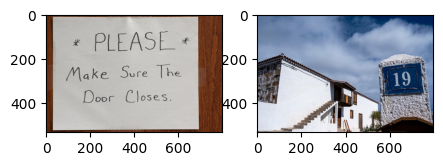

In [3]:
eng_image = Image.open("eng.jpeg")
num_image = Image.open("num.jpeg")

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(5, 5))
axes[0].imshow(eng_image)
axes[1].imshow(num_image)

## Carregar Modelo e Utilizar Modelo

In [4]:
reader = easyocr.Reader(["en"]) # Carrega o modelo de inglês para a memória.

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


['PLEASE', 'Make', 'Sure', 'The', 'Door', 'Closes.']


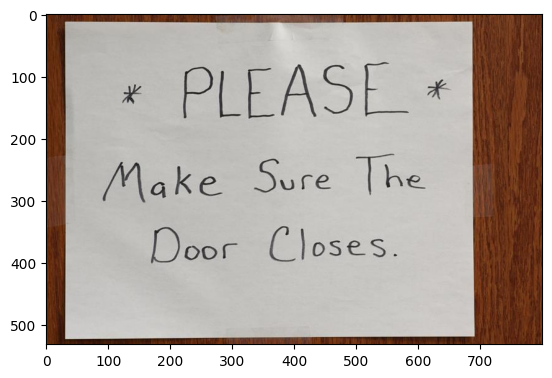

In [5]:
plt.imshow(eng_image)
result = reader.readtext("eng.jpeg", detail=0)
print(result)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


['19']


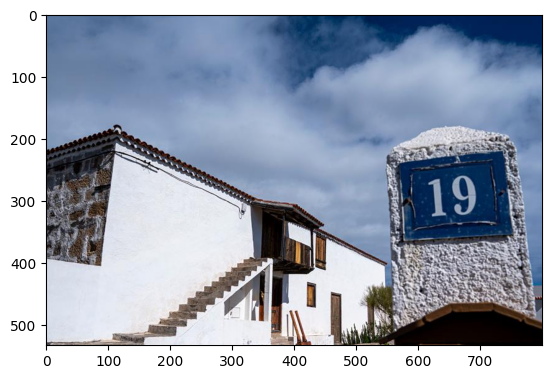

In [6]:
plt.imshow(num_image)
result = reader.readtext("num.jpeg", detail=0)
print(result)

## Próximos Passos e Referências

Nas próximas práticas vamos continuar trabalhando com problemas reais que envolvem Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://github.com/JaidedAI/EasyOCR
- https://www.jaided.ai/easyocr/
- https://huggingface.co
- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opcional)

- [ ] Tente alterar as imagens utilizadas nos testes (outras línguas, placas ou embalagens).
- [x] **Atividade Opcional: Extração de Bounding Boxes com `detail=1`**
  Vamos configurar o EasyOCR para retornar caixas delimitadoras e desenhá-las sobre as imagens usando a biblioteca PIL (`ImageDraw`).

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Texto detectado em eng.jpeg:
- 'PLEASE' (Confiança: 0.994)
- 'Make' (Confiança: 1.000)
- 'Sure' (Confiança: 0.999)
- 'The' (Confiança: 0.993)
- 'Door' (Confiança: 0.998)
- 'Closes.' (Confiança: 0.970)


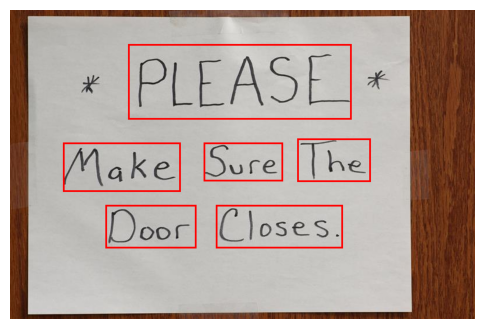

Texto detectado em num.jpeg:
- '19' (Confiança: 0.969)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


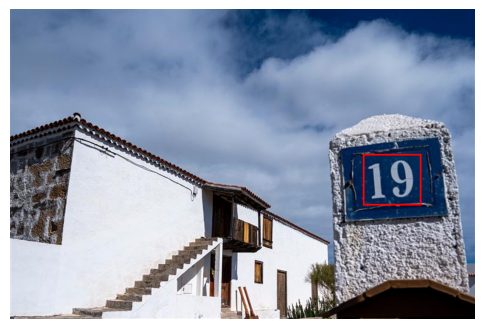

In [7]:
from PIL import ImageDraw

def plot_ocr_results(image_path):
    # Executar OCR com detail=1 para obter coordenadas das caixas
    results_detail = reader.readtext(image_path, detail=1)
    
    # Abrir imagem original e desenhar caixas
    img = Image.open(image_path)
    draw = ImageDraw.Draw(img)
    
    print(f"Texto detectado em {image_path}:")
    for bbox, text, confidence in results_detail:
        print(f"- '{text}' (Confiança: {confidence:.3f})")
        # bbox é uma lista de 4 pontos: [[x0,y0], [x1,y1], [x2,y2], [x3,y3]]
        # Achatamos para passar para polygon do PIL: [x0,y0,x1,y1,x2,y2,x3,y3]
        points = [coord for pt in bbox for coord in pt]
        draw.polygon(points, outline="red", width=3)
        
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# Testando a função de desenho nas duas imagens originais
plot_ocr_results("eng.jpeg")
plot_ocr_results("num.jpeg")

- [x] **Atividade Opcional: Teste de OCR no Team Sonic**
  Vamos buscar se existe algum texto legível na imagem do Sonic (`img/sonic.jpg`) e destacar os locais encontrados.

Imagem do Sonic encontrada em: /content/sonic.jpg
Texto detectado em /content/sonic.jpg:


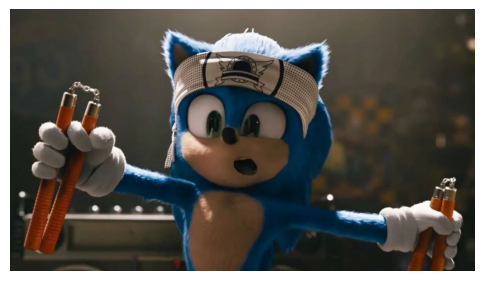

In [8]:
import os

# Caminho da imagem do Sonic
sonic_path = "/content/sonic.jpg"
if not os.path.exists(sonic_path):
    sonic_path = "sonic.jpg"
if not os.path.exists(sonic_path):
    sonic_path = "../../img/sonic.jpg"
if not os.path.exists(sonic_path):
    sonic_path = "img/sonic.jpg"

if not os.path.exists(sonic_path):
    print("ERRO: Imagem do Sonic não encontrada!")
else:
    print(f"Imagem do Sonic encontrada em: {sonic_path}")
    plot_ocr_results(sonic_path)